In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
# import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import math
from sklearn.preprocessing import MinMaxScaler

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Data import class
class TrainDataset(Dataset):
    
    def __init__(self, xy, track=50):
        #data loading
        x0 = torch.from_numpy(xy[:,1:])
        self.n_samples = xy.shape[0]
        self.y = torch.from_numpy(xy[:,[0]]).float()
        self.x = torch.zeros(x0.shape[0], track, x0.shape[1]) # blank tensor for multi-rows of tracking number (say 50)
        for i in range(x0.shape[0]-track): # loop for allocation of past x of tracking number (say 50)
            self.x[i] = x0[i+1:i+1+track]
    
    def __getitem__(self,index):
        return self.x[index], self.y[index]
    
    def __len__(self):
        return self.n_samples

In [3]:
# Data import class
class TestDataset(Dataset):
    
    def __init__(self, xy, track=50):
        #data loading
        x0 = torch.from_numpy(xy[:,1:])
        self.n_samples = xy.shape[0]
        y0 = torch.from_numpy(xy[:,[0]]).float()
        self.y = np.insert(y0,0,y0[0])[:-1] # since we don't know tomorrow's stock, put it same as today
        self.x = torch.zeros(x0.shape[0], track, x0.shape[1]) # blank tensor for multi-rows of tracking number (say 50)
        for i in range(x0.shape[0]-track): # loop for allocation of past x of tracking number (say 50)
            self.x[i] = x0[i+0:i+0+track]
    
    def __getitem__(self,index):
        return self.x[index], self.y[index]
    
    def __len__(self):
        return self.n_samples

In [4]:
# Model class
class NeuralNet(nn.Module):
    def __init__(self, ni, h1, h2, h3, h4, no):
        super(NeuralNet,self).__init__()
        self.input_size = ni
        self.l1 = nn.Linear(ni, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(h1,h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.l3 = nn.Linear(h2,h3)
        self.bn3 = nn.BatchNorm1d(h3)
        self.l4 = nn.Linear(h3,h4)
        self.bn4 = nn.BatchNorm1d(h4)
        self.l5 = nn.Linear(h4,no)
    
    def forward(self, x):
        out = self.l1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.l2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.l3(out) # No softmax(relu)
        out = self.relu(out)
        out = self.l4(out)
        out = self.relu(out)
        out = self.l5(out)
        return out

In [9]:
# preprocessing #takeout hynix and merge with index
df_stocks = pd.read_csv('./Stock_All.csv')
df_pred = pd.DataFrame() # dummy frame
ls_stock = df_stocks.columns[1:] # list of the stock names  
print(ls_stock)

Index(['aapl', 'amzn', 'goog', 'tsla'], dtype='object')


In [10]:
#for j in range(len(stock)):
j = 1

In [11]:
# Hyper-parameters 
num_epochs = 50
batch_size = 500
tracking_day = 30
learning_rate = 0.0005
h1 = 50
h2 = 50
h3 = 50
h4 = 50
no = 1

In [12]:
name = stock[j]
df_stock = df_stocks[['date',name]] 
#---> need to plug the number i for iteration 
df_index = pd.read_csv('./Index_All.csv')
df = pd.merge(df_stock, df_index, "inner")
#pop df_date
df_date = df.pop('date')
#make df_pct
df_pct = df.pct_change(-1)*100
df_pct['date'] = df_date
df_pct = df_pct.dropna()
# scale for x (=df_pct) #scikit learn scaler
scaler = MinMaxScaler((-1,1)) 
scaler.fit(df_pct)
xy = scaler.transform(df_pct)
xy[:,0] = df_pct.values[:,0] #revoke y values
xy = xy[:,:-1] #remove date
ls_index = df_index.columns[1:] # list of the stock names  
print(ls_index)

Index(['gold', 'oil', 'dollar', 'btc'], dtype='object')


In [13]:
# Load data
dataset = TrainDataset(xy,tracking_day)
dataloader = DataLoader(dataset = dataset, batch_size = batch_size, 
                        shuffle=True)#, num_workers=2)

# number of input neurons (automated)
ni = tracking_day*dataset.x.shape[2]
# Model create
model = NeuralNet(ni, h1, h2, h3, h4, no)
# Loss
criterion = nn.SmoothL1Loss()
# criterion = nn.MSELoss()
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# training loop
n_total_steps = len(dataloader) # len(y)/batch_size (ex. 1318/100 => 14 loads)

In [14]:
for epoch in range(num_epochs):
    model.train()

    for i, (x,y) in enumerate(dataloader):
        # [100, 80, 7] --> [100, 80*7]  // y= [100, 1]
        x = x.reshape(x.shape[0], -1).to(device)
        y = y.to(device)
        #Forward
        y_pred = model(x)
        loss = criterion(y_pred, y)
        #Backward
        optimizer.zero_grad() #gradient clear
        loss.backward() #back propagation
        optimizer.step() #update weights

        if (epoch+1) % 10 ==0: 
            if (i+1) % 1 == 0:
                print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.5f}')

Epoch [10/50], Step [1/1], Loss: 0.89983
Epoch [20/50], Step [1/1], Loss: 0.85763
Epoch [30/50], Step [1/1], Loss: 0.77557
Epoch [40/50], Step [1/1], Loss: 0.62597
Epoch [50/50], Step [1/1], Loss: 0.40565


In [15]:
# save and load entire model
FILE = f'./model_{name}.pth'
torch.save(model, FILE)

In [16]:
# Load TestDataset
testset = TestDataset(xy,tracking_day)
x1 = testset.x
x1 = x1.reshape(x1.shape[0],-1)
y1 = testset.y
y1_pred = model(x1)

In [17]:
# build df_pred
df_pct1 = df_pct.head(1)
df_pct = pd.concat([df_pct, df_pct1]).sort_index().reset_index(drop=True)
df_pct.date.iloc[0] = df_pct.date.iloc[0]+1
df_pct = df_pct [:-1]
#df_pct['datetime'] = df_pct['date'].apply(lambda x: pd.to_datetime(str(x), format='%Y%m%d'))
df_pct['pred'] = y1_pred.squeeze().tolist()

print(x)

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.1019, -0.2820, -0.1595,  ..., -0.0502,  0.0770, -0.2820],
        [-0.2971,  0.1799,  0.1861,  ..., -0.3132,  0.0056, -0.2968],
        ...,
        [-0.1709, -0.2193,  0.0419,  ..., -0.1455,  0.0932, -0.2420],
        [-0.5931, -0.4866, -0.2058,  ..., -0.2421, -0.1540, -0.2012],
        [-0.4191, -0.5721, -0.2178,  ..., -0.2108, -0.0660, -0.3556]])


C:\Users\Juan\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


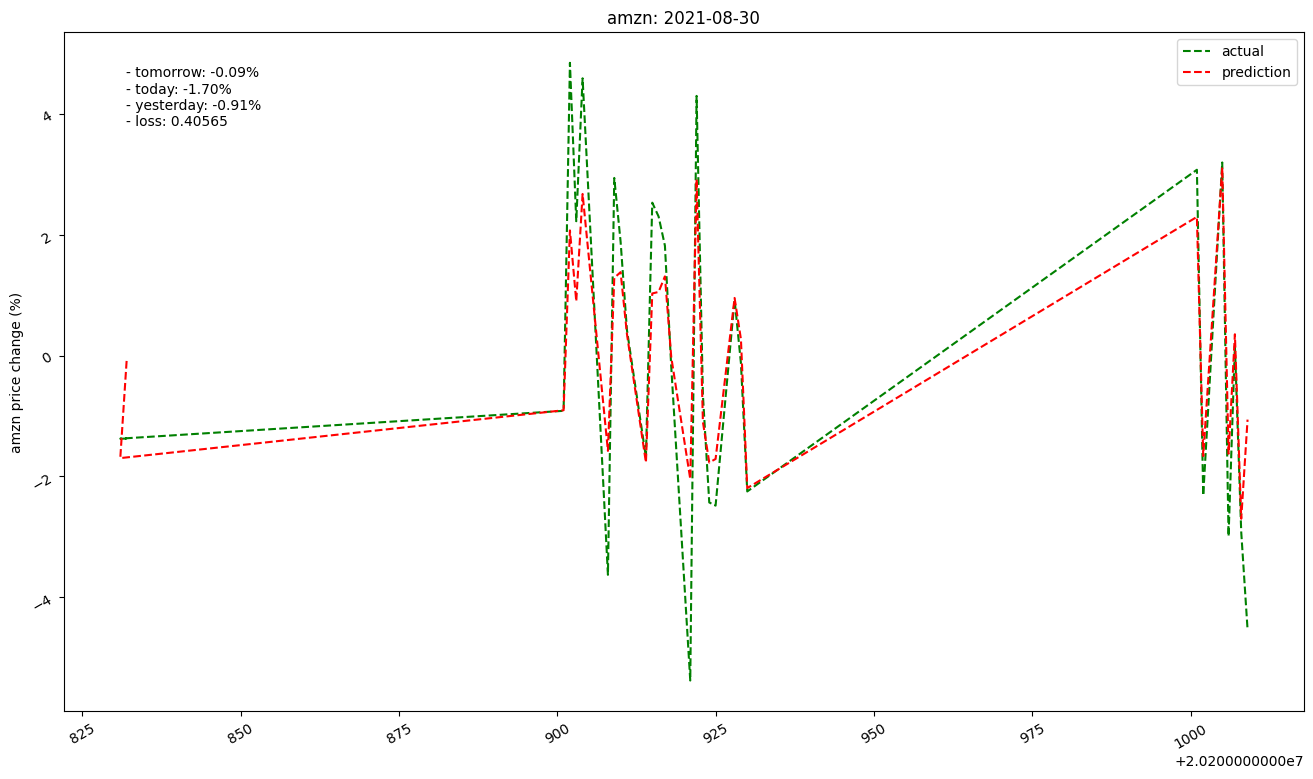

In [34]:
# Visualize
from datetime import date
today = date.today()

fig = plt.figure(figsize=(16,9), dpi=100)
ax = fig.add_subplot(111)
no=30
#ax.plot(df_pct.datetime[:no],df_pct[f'{name}'][:no],label = 'actual')
#ax.plot(df_pct.datetime[:no],df_pct.pred[:no],'r--',label = 'prediction')
ax.plot(df_pct.date[:no],df_pct[f'{name}'][:no],'g--',label = 'actual')
ax.plot(df_pct.date[:no],df_pct.pred[:no],'r--',label = 'prediction')
ax.legend()
ax.set_ylabel(f'{name} price change (%)')
ax.set_title(f'{name}: {today}')
plt.xticks(rotation=30)
plt.yticks(rotation=30)
# save prediction in dataframe df_pred
pct = y1_pred.data.squeeze().tolist()[:5]
df_single = pd.DataFrame(pct,columns=[f'{name}'])
df_single.round(2)
df_pred = pd.concat([df_pred,df_single],axis=1)
ax.text(0.05, 0.95, 
        f'- tomorrow: {df_pct.pred[0]:2.2f}%\n- today: {df_pct.pred[1]:2.2f}%\n- yesterday: {df_pct.pred[2]:2.2f}%\n- loss: {loss.item():.5f}',
        ha='left', va='top', transform=ax.transAxes)
fig.savefig(f'./{today}_{name}')

In [42]:
#df_pred['datetime'] = df_pct.datetime
df_pred['date'] = df_pct.date
df_pred.to_csv('./sum.csv')
df_single.round(2)


,amzn
0,-0.09
1,-1.70
2,-0.91
3,2.07
4,0.90
